In [1]:
import torch 
from torch import nn
import torch.optim as optim
from data_tuning.data_utils import create_data_loaders
from transformer_code import ViT
from transformer_utils import train, test, load_checkpoint, Scheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
device

output: torch.Size([4, 257, 256])
attention_out: torch.Size([4, 257, 64])
attention_probs: torch.Size([4, 257, 257])
wejscie: torch.Size([4, 257, 256])
wyjscie: torch.Size([4, 257, 256])
MLP wejscie: torch.Size([4, 257, 256])
MLP wyjscie: torch.Size([4, 257, 256])
TransformerBlock wejscie: torch.Size([4, 257, 256])
TransformerBlock wyjscie: torch.Size([4, 257, 256])
Encoder wejscie: torch.Size([4, 257, 256])
Encoder wyjscie: torch.Size([4, 257, 256])
ViT wejście (obrazy): torch.Size([4, 3, 256, 256])
ViT wyjście (logity): torch.Size([4, 2])


'cuda'

In [2]:
data_dir = "C:/Users/Maria/Desktop/datasets/pneumonia_chest_xray/transformed/"

In [3]:
batch_size = 32
dataloaders = create_data_loaders(data_dir, batch_size, 4)
train_loader = dataloaders[0]
val_loader = dataloaders[1]
test_loader = dataloaders[2]
print(train_loader.dataset.classes)

['BACTERIA', 'NORMAL', 'VIRUS']


In [6]:
if False:

    from collections import Counter
    
    all_test_labels = []
    for _, labels in test_loader:
        all_test_labels.extend(labels.numpy())
    
    all_train_labels = []
    for _, labels in train_loader:
        all_train_labels.extend(labels.numpy())   
    
    print("Rozkład klas w zbiorze testowym:", Counter(all_test_labels))
    print("Rozkład klas w zbiorze treningowym:", Counter(all_train_labels))

Rozkład klas w zbiorze testowym: Counter({np.int64(0): 242, np.int64(1): 234, np.int64(2): 148})
Rozkład klas w zbiorze treningowym: Counter({np.int64(0): 3027, np.int64(2): 1710, np.int64(1): 1706})


In [4]:
if False:
    
    model_1 = ViT(
        image_size=256,
        patch_size=16,
        channels=3,
        embedding_size=256,
        num_layers=6,
        n_heads=8,
        num_classes=3,
        dropout=0.3
    )
    model_1.to(device)

ViT(
  (embedding): PatchEmbedding(
    (projection): Conv2d(3, 256, kernel_size=(16, 16), stride=(16, 16))
  )
  (encoder): Encoder(
    (blocks): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): MultiHeadAttention(
          (heads): ModuleList(
            (0-7): 8 x AttentionHead(
              (query): Linear(in_features=256, out_features=32, bias=True)
              (key): Linear(in_features=256, out_features=32, bias=True)
              (value): Linear(in_features=256, out_features=32, bias=True)
              (dropout): Dropout(p=0.2, inplace=False)
            )
          )
          (combined): Linear(in_features=256, out_features=256, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (layernorm_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (dense_1): Linear(in_features=256, out_features=1024, bias=True)
          (activation): GELU(approximate='none')
          (dense_2): Linear(in_fea

Do train dodałam parametr resume. Jeśli chcemy trenować model od 0, to dajemy False. Jeśli damy True, to funkcja wyczyta ostatni checkpoint z pliku (folder na checkpointy robi się automatycznie) i będzie kontynuować trening od tego momentu. Logi zapisuję do pliku csv (może się przydać jak będziemy trenować na raty).

In [5]:
if False:
    
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_1.parameters(), lr=0.001)
    
    train(
        model=model_1,
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        n_epochs=50,
        batch_size=32,
        patience = 5,
        device=device,
        save_dir='transformer_checkpoints',
        model_name='vit_1',
        resume=False
    )

Epoch 1/50: 100%|███████████████████████████████████████████| 202/202 [03:27<00:00,  1.03s/it, loss=0.9703, acc=41.46%]


[Epoch: 1] Train loss: 1.24 | Train acc: 41.46% | Val loss: 1.14 | Val acc: 48.37%

Nowy najlepszy model: Val acc: 48.37% (epoch 1)


Epoch 2/50: 100%|███████████████████████████████████████████| 202/202 [03:29<00:00,  1.04s/it, loss=0.9260, acc=49.62%]


[Epoch: 2] Train loss: 1.01 | Train acc: 49.62% | Val loss: 0.87 | Val acc: 47.80%


Epoch 3/50: 100%|███████████████████████████████████████████| 202/202 [03:26<00:00,  1.02s/it, loss=1.0935, acc=58.84%]


...

[Epoch: 27] Train loss: 0.57 | Train acc: 73.94% | Val loss: 0.66 | Val acc: 76.48%

Early stopping po 27 epokach (patience: 5)


Epoch 28/50: 100%|██████████████████████████████████████████| 202/202 [03:25<00:00,  1.02s/it, loss=0.4342, acc=73.04%]


[Epoch: 28] Train loss: 0.59 | Train acc: 73.04% | Val loss: 0.64 | Val acc: 73.04%

Early stopping po 28 epokach (patience: 5)


Epoch 29/50:  72%|██████████████████████████████▎           | 146/202 [02:34<00:59,  1.06s/it, loss=0.8562, acc=74.14%]


KeyboardInterrupt: 

Testowanie: 100%|██████████████████████████████████████████████████████████████████████| 20/20 [00:29<00:00,  1.46s/it]



--- Test Results ---
Loss:      1.3628
Accuracy:  65.06%
Precision: 0.7213
Recall:    0.6506
F1 Score:  0.6321


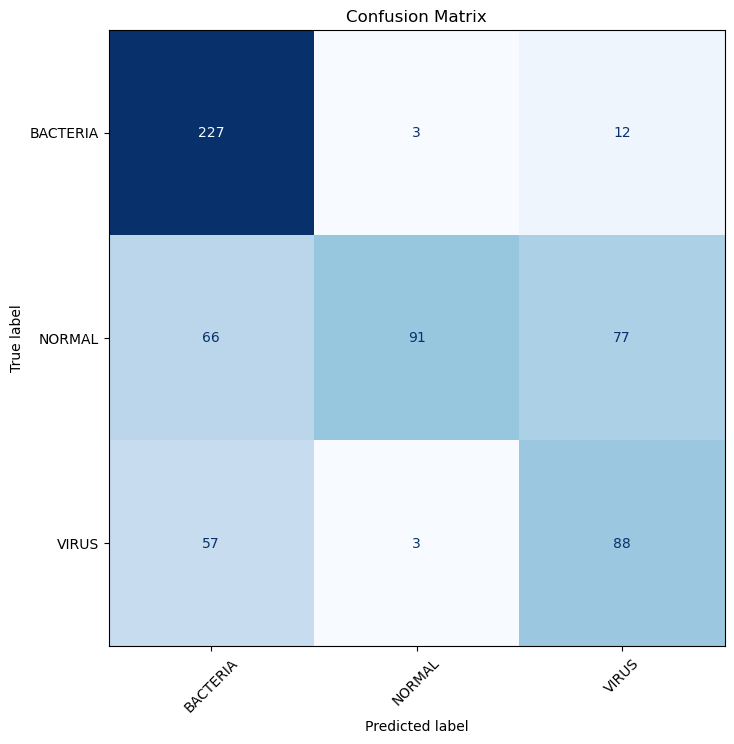

In [6]:
if False:

    test(
        model=model_1,
        dataloader=test_loader,
        loss_fn=loss_fn,
        device=device,
        save_dir='transformer_checkpoints',
        model_name='vit_1'
    )

In [4]:
model_2 = ViT(
    image_size=256,
    patch_size=32,
    channels=3,
    embedding_size=384,
    num_layers=8,
    n_heads=12,
    num_classes=3,
    dropout=0.4
)
model_2.to(device)

ViT(
  (embedding): PatchEmbedding(
    (projection): Conv2d(3, 384, kernel_size=(32, 32), stride=(32, 32))
  )
  (encoder): Encoder(
    (blocks): ModuleList(
      (0-7): 8 x TransformerBlock(
        (attention): MultiHeadAttention(
          (heads): ModuleList(
            (0-11): 12 x AttentionHead(
              (query): Linear(in_features=384, out_features=32, bias=True)
              (key): Linear(in_features=384, out_features=32, bias=True)
              (value): Linear(in_features=384, out_features=32, bias=True)
              (dropout): Dropout(p=0.2, inplace=False)
            )
          )
          (combined): Linear(in_features=384, out_features=384, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (layernorm_1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (dense_1): Linear(in_features=384, out_features=1536, bias=True)
          (activation): GELU(approximate='none')
          (dense_2): Linear(in_f

In [5]:
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model_2.parameters(), 
    lr=0.00002,
    weight_decay=0.1
)

steps_per_epoch = len(train_loader)

scheduler = Scheduler(
    optimizer=optimizer,
    warmup_epochs=5, # 5 rozgrzewkowych
    total_epochs=50,
    max_lr=0.00002,
    steps_per_epoch=steps_per_epoch
)

Epoch 1/50: 100%|██████████████████████████████| 202/202 [02:33<00:00,  1.31it/s, loss=0.9591, acc=43.94%, lr=4.00e-06]


[Epoch: 1] Train loss: 1.09 | Train acc: 43.94% | Val loss: 1.05 | Val acc: 48.37%

Nowy najlepszy model: Val acc: 48.37% (epoch 1)



Epoch 2/50: 100%|██████████████████████████████| 202/202 [02:22<00:00,  1.41it/s, loss=1.1591, acc=47.42%, lr=8.00e-06]


[Epoch: 2] Train loss: 1.05 | Train acc: 47.42% | Val loss: 0.99 | Val acc: 48.18%


Epoch 3/50: 100%|██████████████████████████████| 202/202 [02:18<00:00,  1.46it/s, loss=0.7343, acc=56.67%, lr=1.20e-05]


...

[Epoch: 33] Train loss: 0.60 | Train acc: 82.03% | Val loss: 0.61 | Val acc: 81.84%


Epoch 34/50: 100%|█████████████████████████████| 202/202 [02:08<00:00,  1.57it/s, loss=0.6573, acc=81.83%, lr=7.11e-06]


[Epoch: 34] Train loss: 0.60 | Train acc: 81.83% | Val loss: 0.61 | Val acc: 82.03%


Epoch 35/50: 100%|█████████████████████████████| 202/202 [02:10<00:00,  1.55it/s, loss=0.4720, acc=82.45%, lr=6.67e-06]


[Epoch: 35] Train loss: 0.59 | Train acc: 82.45% | Val loss: 0.62 | Val acc: 81.07%

Zapisano checkpoint: transformer_checkpoints\vit_2_checkpoint_epoch_35.pth


Early stopping po 35 epokach (patience: 8)


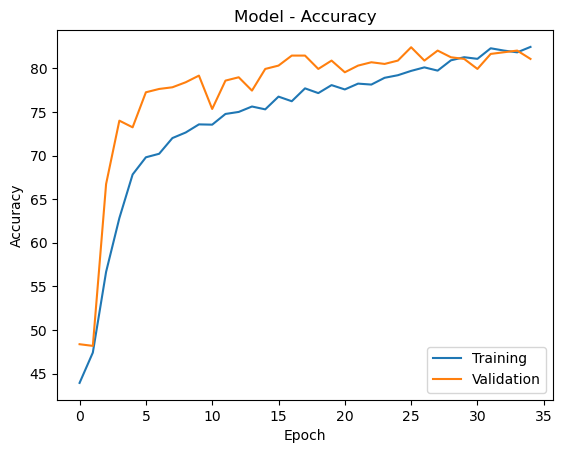

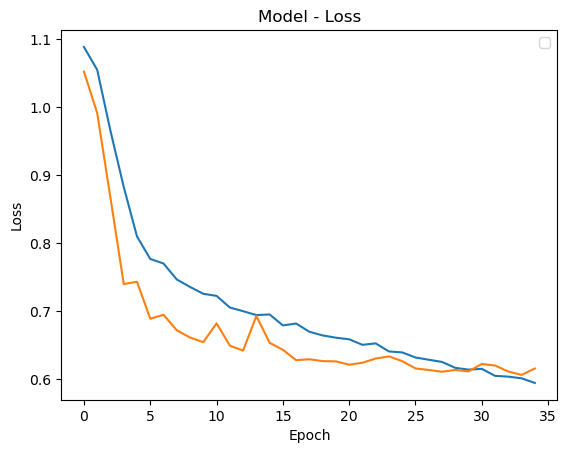

In [6]:
train(
    model=model_2,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    n_epochs=50,
    batch_size=32,
    patience=8,
    device=device,
    save_dir='transformer_checkpoints',
    model_name='vit_2',
    resume=False,
    scheduler=scheduler,
    gradient_clipping=1.0 
)

C:\Users\Maria\AppData\Local\Temp\ipykernel_24200\1553432181.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('transformer_checkpoints/vit_2_best.


--- Test Results ---
Loss:      0.9805
Accuracy:  67.31%
Precision: 0.7863
Recall:    0.6731
F1 Score:  0.6514


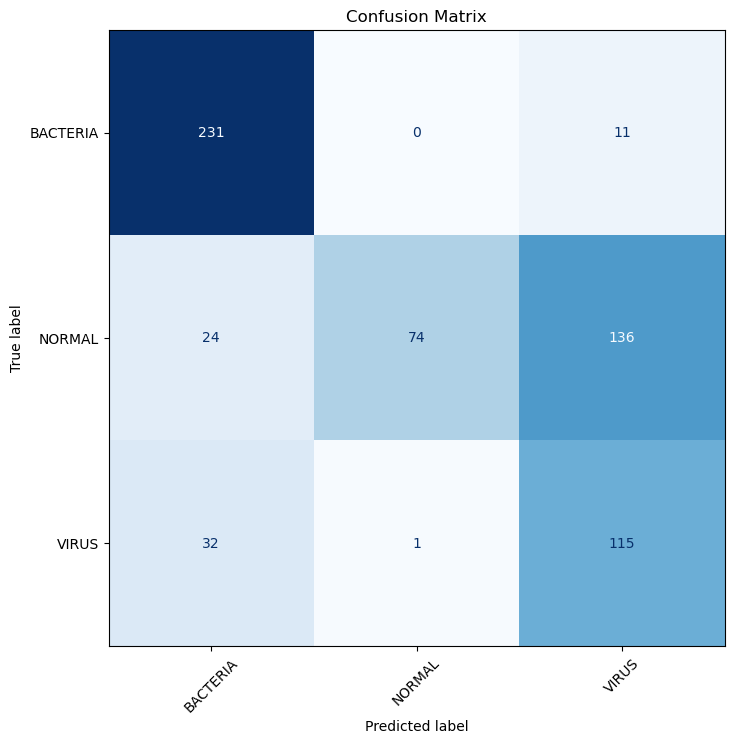

In [8]:
# przywracam najlepszy
checkpoint = torch.load('transformer_checkpoints/vit_2_best.pth', map_location=device)
model_2.load_state_dict(checkpoint['model_state_dict'])

test(
    model=model_2,
    dataloader=test_loader,
    loss_fn=loss_fn,
    device=device,
    save_dir='transformer_checkpoints',
    model_name='vit_2'
)